In [1]:
import pandas as pd
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
df.shape
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [7]:
Target = "price"
df.isnull().sum()
features = df.drop("price", axis=1).columns
print("Target:", Target)
print("Features:", list(features))

Target: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [8]:
df.drop_duplicates(inplace=True)
print(df.isnull().sum())
df = pd.get_dummies(df, drop_first=True)
print(df.head())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          Tr

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

X = df.drop("price", axis=1)
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)

Linear Regression
MAE : 970043.4039201637
RMSE: 1324506.9600914388
R2 : 0.6529242642153184


In [11]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 :", rf_r2)


Random Forest
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R2 : 0.611918531405699


In [12]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae,rf_mae],
    "RMSE":[rmse,rf_rmse],
    "R2 Score":[r2,rf_r2]
})
print(comparison)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


In [16]:
import os
os.makedirs("charts", exist_ok=True)

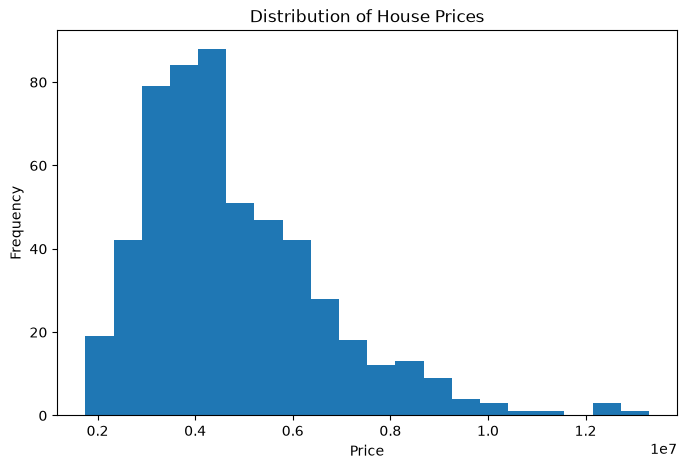

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png")
plt.show()

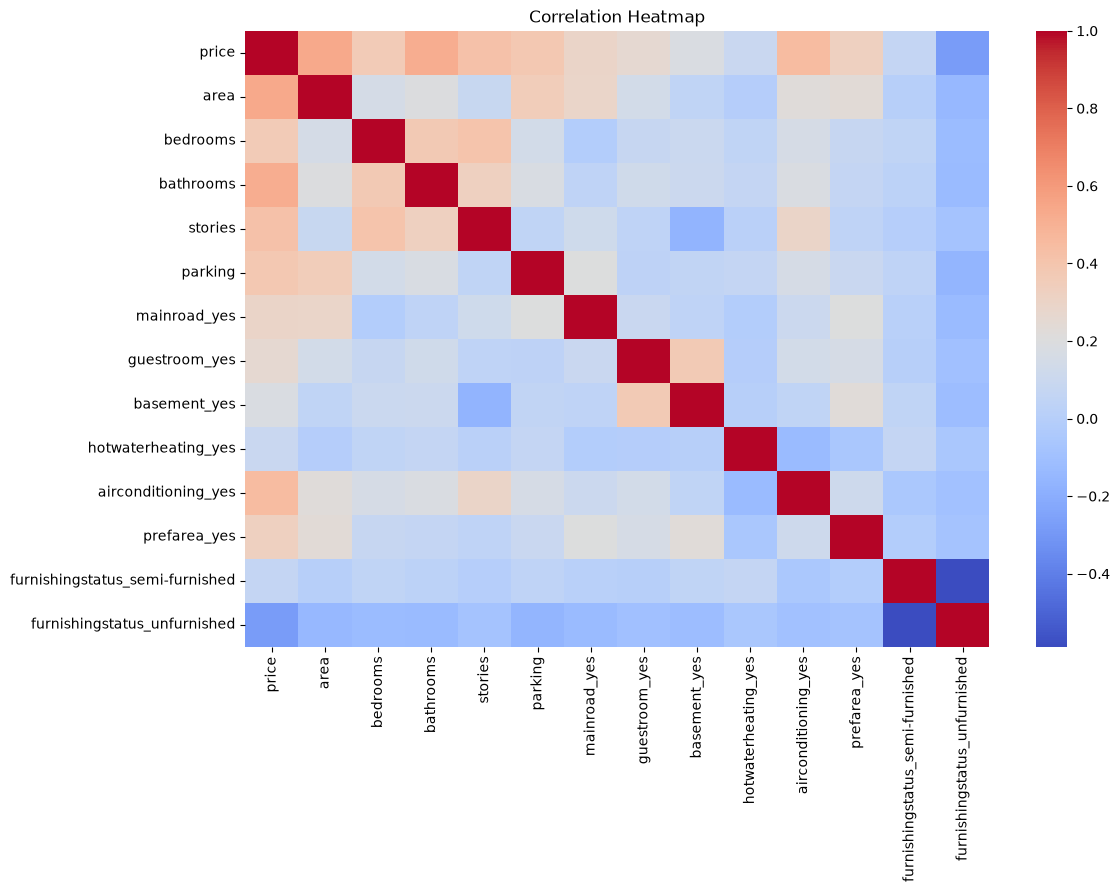

In [18]:
import seaborn as sns
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.savefig("charts/correlation_heatmap.png")
plt.show()

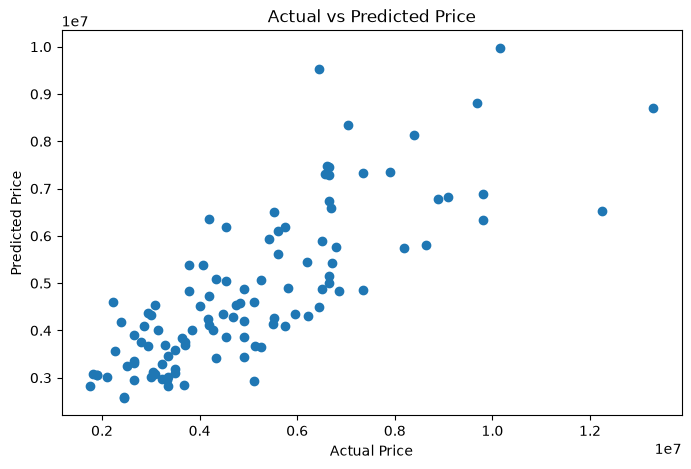

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.savefig("charts/actual_vs_predicted.png")
plt.show()

In [ ]:
#Findings

#The House Price Prediction project was developed using Linear Regression and Random Forest Regression models. 
#The data analysis showed that area, number of bathrooms, stories, and parking facilities had the strongest influence on house prices. 
#After evaluating both models, the Random Forest Regressor achieved better prediction accuracy than Linear Regression, indicating its ability to capture complex relationships among features.
#The dataset contained a wide range of property prices, with larger houses generally costing more. 
#One interesting observation was that furnishing status also affected property value significantly. 
#Based on these findings, real estate businesses should focus on highlighting area, amenities, and furnishing quality when pricing or marketing properties.

#Technologies Used
#Python 3.x
#Pandas
#NumPy
#Matplotlib
#Seaborn
#Scikit-Learn
#Jupyter Notebook